# 04 — Risk Analysis: Drawdown and Rolling Volatility

## Objective

The objective of this notebook is to analyze the risk profile of the momentum strategy
and compare it with the FEZ benchmark.

We focus on:
- drawdowns to measure downside risk
- maximum drawdown to quantify worst-case losses
- rolling volatility to assess how risk evolves over time

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load Backtest Data

We reuse the backtest summary table containing:
- monthly returns
- equity curves

In [2]:
backtest_summary = pd.read_csv("../data/backtest_summary.csv", index_col=0, parse_dates=True)

strategy_equity = backtest_summary["Strategy Equity"]
benchmark_equity = backtest_summary["FEZ Equity"]

strategy_returns = backtest_summary["Strategy Return"]
benchmark_returns = backtest_summary["FEZ Return"]

## 2. Drawdown

Drawdown measures the decline from a previous peak in the portfolio value.

**Drawdown = (Portfolio Value - Running Maximum) / Running Maximum**

It represents the percentage loss from the last peak.

Why it matters:
- captures downside risk
- reflects investor experience (losses matter more than gains)


## 3. Drawdown Plot

This plot shows the evolution of drawdowns over time for both the strategy and the benchmark.

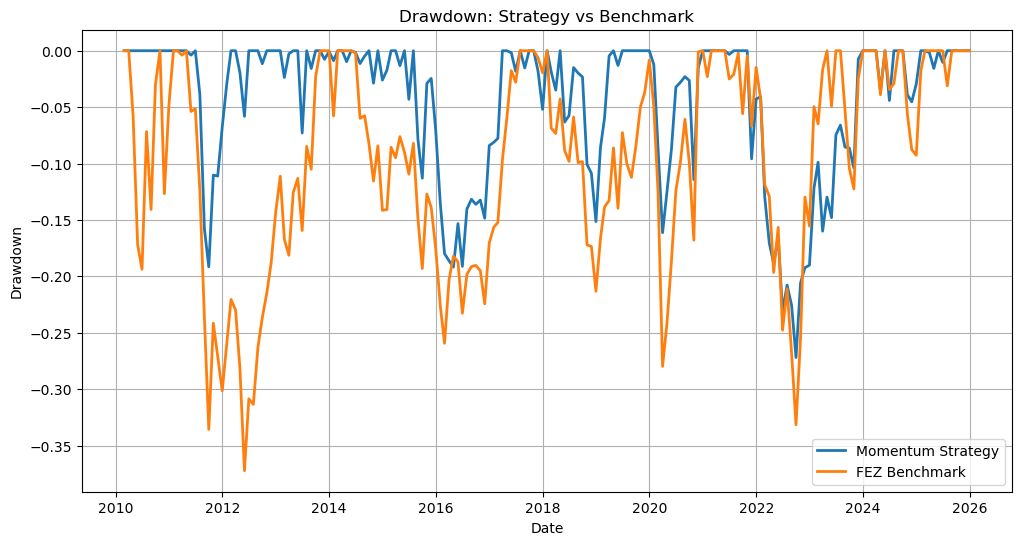

In [7]:
# Running maximum
strategy_peak = strategy_equity.cummax()
benchmark_peak = benchmark_equity.cummax()

# Drawdown
strategy_drawdown = (strategy_equity - strategy_peak) / strategy_peak
benchmark_drawdown = (benchmark_equity - benchmark_peak) / benchmark_peak

plt.figure(figsize=(12, 6))
plt.plot(strategy_drawdown, label="Momentum Strategy", linewidth=2)
plt.plot(benchmark_drawdown, label="FEZ Benchmark", linewidth=2)
plt.title("Drawdown: Strategy vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

## 4. Maximum Drawdown

Maximum drawdown represents the largest observed loss from peak to trough.

**Max Drawdown = min(drawdown)**

Why it matters:
- measures worst-case loss
- critical for risk management

In [4]:
strategy_max_dd = strategy_drawdown.min()
benchmark_max_dd = benchmark_drawdown.min()

print("Strategy Max Drawdown:", f"{strategy_max_dd:.2%}")
print("Benchmark Max Drawdown:", f"{benchmark_max_dd:.2%}")

Strategy Max Drawdown: -27.19%
Benchmark Max Drawdown: -37.23%


## 5. Rolling Volatility (12 months)

Rolling volatility measures how risk evolves over time.

**Rolling Volatility = std(last 12 months returns) × √12**

Why it matters:
- captures changing risk conditions
- identifies periods of stress or instability


## 6. Rolling Volatility Plot

This plot shows how volatility evolves over time for both the strategy and the benchmark.

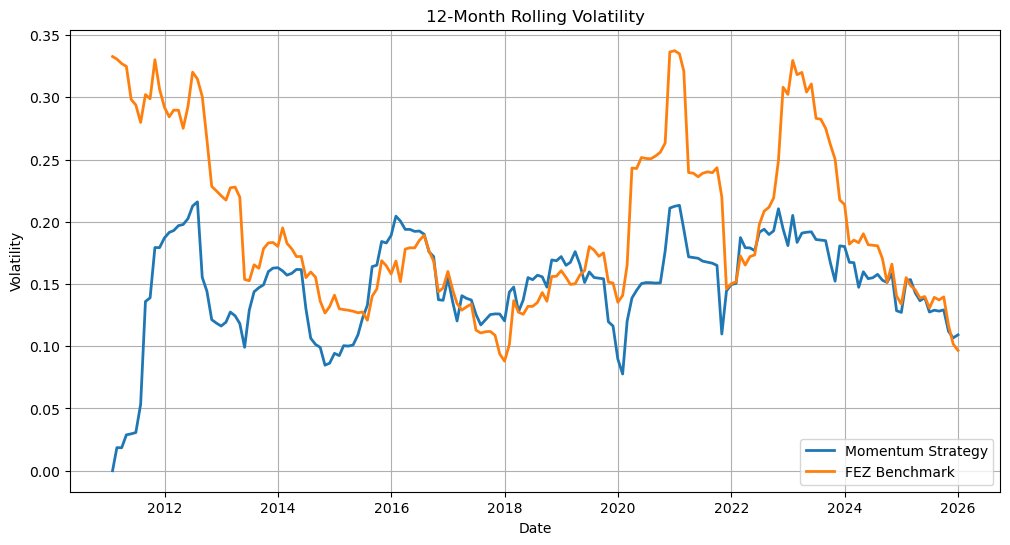

In [5]:
window = 12

strategy_rolling_vol = strategy_returns.rolling(window).std() * np.sqrt(12)
benchmark_rolling_vol = benchmark_returns.rolling(window).std() * np.sqrt(12)

plt.figure(figsize=(12, 6))
plt.plot(strategy_rolling_vol, label="Momentum Strategy", linewidth=2)
plt.plot(benchmark_rolling_vol, label="FEZ Benchmark", linewidth=2)
plt.title("12-Month Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)
plt.show()

## 7. Interpretation

The drawdown analysis shows the magnitude and duration of losses experienced by the strategy.

If the momentum strategy exhibits deeper or more prolonged drawdowns than the benchmark,
it indicates higher downside risk.

The maximum drawdown provides a worst-case scenario, which is crucial for understanding potential losses.

The rolling volatility analysis highlights how risk evolves over time.
Periods of increased volatility often correspond to market stress or unstable strategy behavior.

Comparing both metrics with the benchmark allows us to assess whether the strategy delivers
better performance at the cost of higher risk, or whether it remains efficient under different market conditions.